In [15]:
from app import get_datasets_as_pandas, get_determinands_as_pandas, get_sites_for_dataset_as_pandas, get_timeseries_for_dataset_and_site_as_pandas, get_timeseries_for_dataset_site_determinand_as_pandas, get_data_for_date_dataset_as_pandas

import datetime
import json
import os.path

import pandas as pd
import requests

import matplotlib.pyplot as plt
import numpy as np

In [64]:
def split_col(s):
    #split into value and qualifier like the ea_bathing_water dataset

    s = s.astype(str).str.strip()

    # Extract qualifier
    qualifier = s.str.extract(r'([<>])')[0].map({
        '<': 'lessThan',
        '>': 'greaterThan'
    }).fillna('actual')

    # Extract numeric part (digits only)
    numeric = pd.to_numeric(s.str.extract(r'(\d+)')[0], errors='coerce')

    return numeric, qualifier

Import data

In [97]:
##### EXAMPLE USAGE #####
# get dataset info as pandas
df_datasets = get_datasets_as_pandas(display=False)
# get determinands info as pandas
df_determinands = get_determinands_as_pandas(display=False)
# get sites info for a single example dataset
df_sites_rainfall = get_sites_for_dataset_as_pandas("rainfall", display=False)
# get timeseries without determinand example
df_timeseries_Oxford_fft = get_timeseries_for_dataset_and_site_as_pandas("Oxford", "fft", display=False)
# get timeseries with determinand example
df_timeseries_Wolvercote_sonde_turbidity = get_timeseries_for_dataset_site_determinand_as_pandas("E01612A", "ea_wq_sonde", "turbidity", display=False)
# get data for date example
df_date_rainfall_2024_07_31 = get_data_for_date_dataset_as_pandas("rainfall", datetime.date(2024, 7, 31), display=False)

##### GET DATA FOR ECOLI #####
# get time series that contain ecoli info
# yields -> [[{'code': 'ea_bathing_water', 'id': 'EC', 'column': 'escherichia coli count'}, {'code': 'wtrt', 'id': 'EC', 'column': 'escherichia coli count'}]]
ecoli_datasets_ids = df_determinands[df_determinands["name"].str.contains("coli", case=False, na=False)]["datasets"].values[0]
ecoli_timeseries_dfs = {}
for dataset in ecoli_datasets_ids:
    dataset_id = dataset["code"]
    determinand_id = dataset["id"]
    for site in get_sites_for_dataset_as_pandas(dataset_id)["properties.id"]:
        df = get_timeseries_for_dataset_site_determinand_as_pandas(site, dataset_id, determinand_id)

        #format both dataset types into a consistent format
        if dataset_id == 'ea_bathing_water':
            # reshape dataframe to have datetime and ecoli/enterococci columns
            columns = ['sample date time', 'escherichia coli count', 'escherichia coli qualifier', 'intestinal enterococci count', 'intestinal enterococci qualifier'] #unique columns, excluding record date which is included in sample date time
            df_new = pd.DataFrame()
            for col in columns:
                mask = df.columns.str.contains(f'{col}.*')
                df_new[col] = pd.Series(df.loc[:, mask].T.values.ravel())

            #format datetime to match
            df_new['datetime'] = pd.to_datetime(df_new['sample date time'])
            df_new = df_new.drop(columns=['sample date time'])
            df_new = df_new.sort_values(by='datetime')

            ecoli_timeseries_dfs[(site, dataset_id)] = df_new
        else:
            try:
                df['datetime'] = pd.to_datetime(df['datetime'])
                df['escherichia coli count'], df['escherichia coli qualifier'] = split_col(df['value']) #split value into count and qualifier e.g. < 10 (value) -> 10 (count) and lessThan (qualifier)
                df = df.drop(columns=['value'])
                df = df.sort_values(by='datetime')
                
                ecoli_timeseries_dfs[(site, dataset_id)] = df
            except Exception as e:
                print(f"Error for site {site} dataset {dataset_id}: {e}") #site 1743499042454x452904883018006500 dataset wtrt is empty
    

Error for site 1743499042454x452904883018006500 dataset wtrt: 'datetime'


Plot e-coli time series

In [100]:
ecoli_timeseries_dfs[('1715107523320x189195058054168580', 'wtrt')].head(10)

,datetime,escherichia coli count,escherichia coli qualifier
0,2024-05-18 23:00:00+00:00,621.0,actual
1,2024-05-22 23:00:00+00:00,2963.0,actual
2,2024-05-29 14:26:21.104000+00:00,2229.0,actual
3,2024-05-30 17:05:08.873000+00:00,716.0,actual
4,2024-05-30 23:00:00+00:00,1097.0,actual
5,2024-05-31 23:00:00+00:00,952.0,actual
6,2024-06-01 23:00:00+00:00,1097.0,actual
7,2024-06-02 23:00:00+00:00,951.0,actual
9,2024-06-03 23:00:00+00:00,1264.0,actual
8,2024-06-04 06:36:15.235000+00:00,NaN,actual


Something odd with the time stamps here - seems unlikely that a measurement was taken at 17:05... and 23:00:00 on the same day?

ValueError: cannot reindex on an axis with duplicate labels

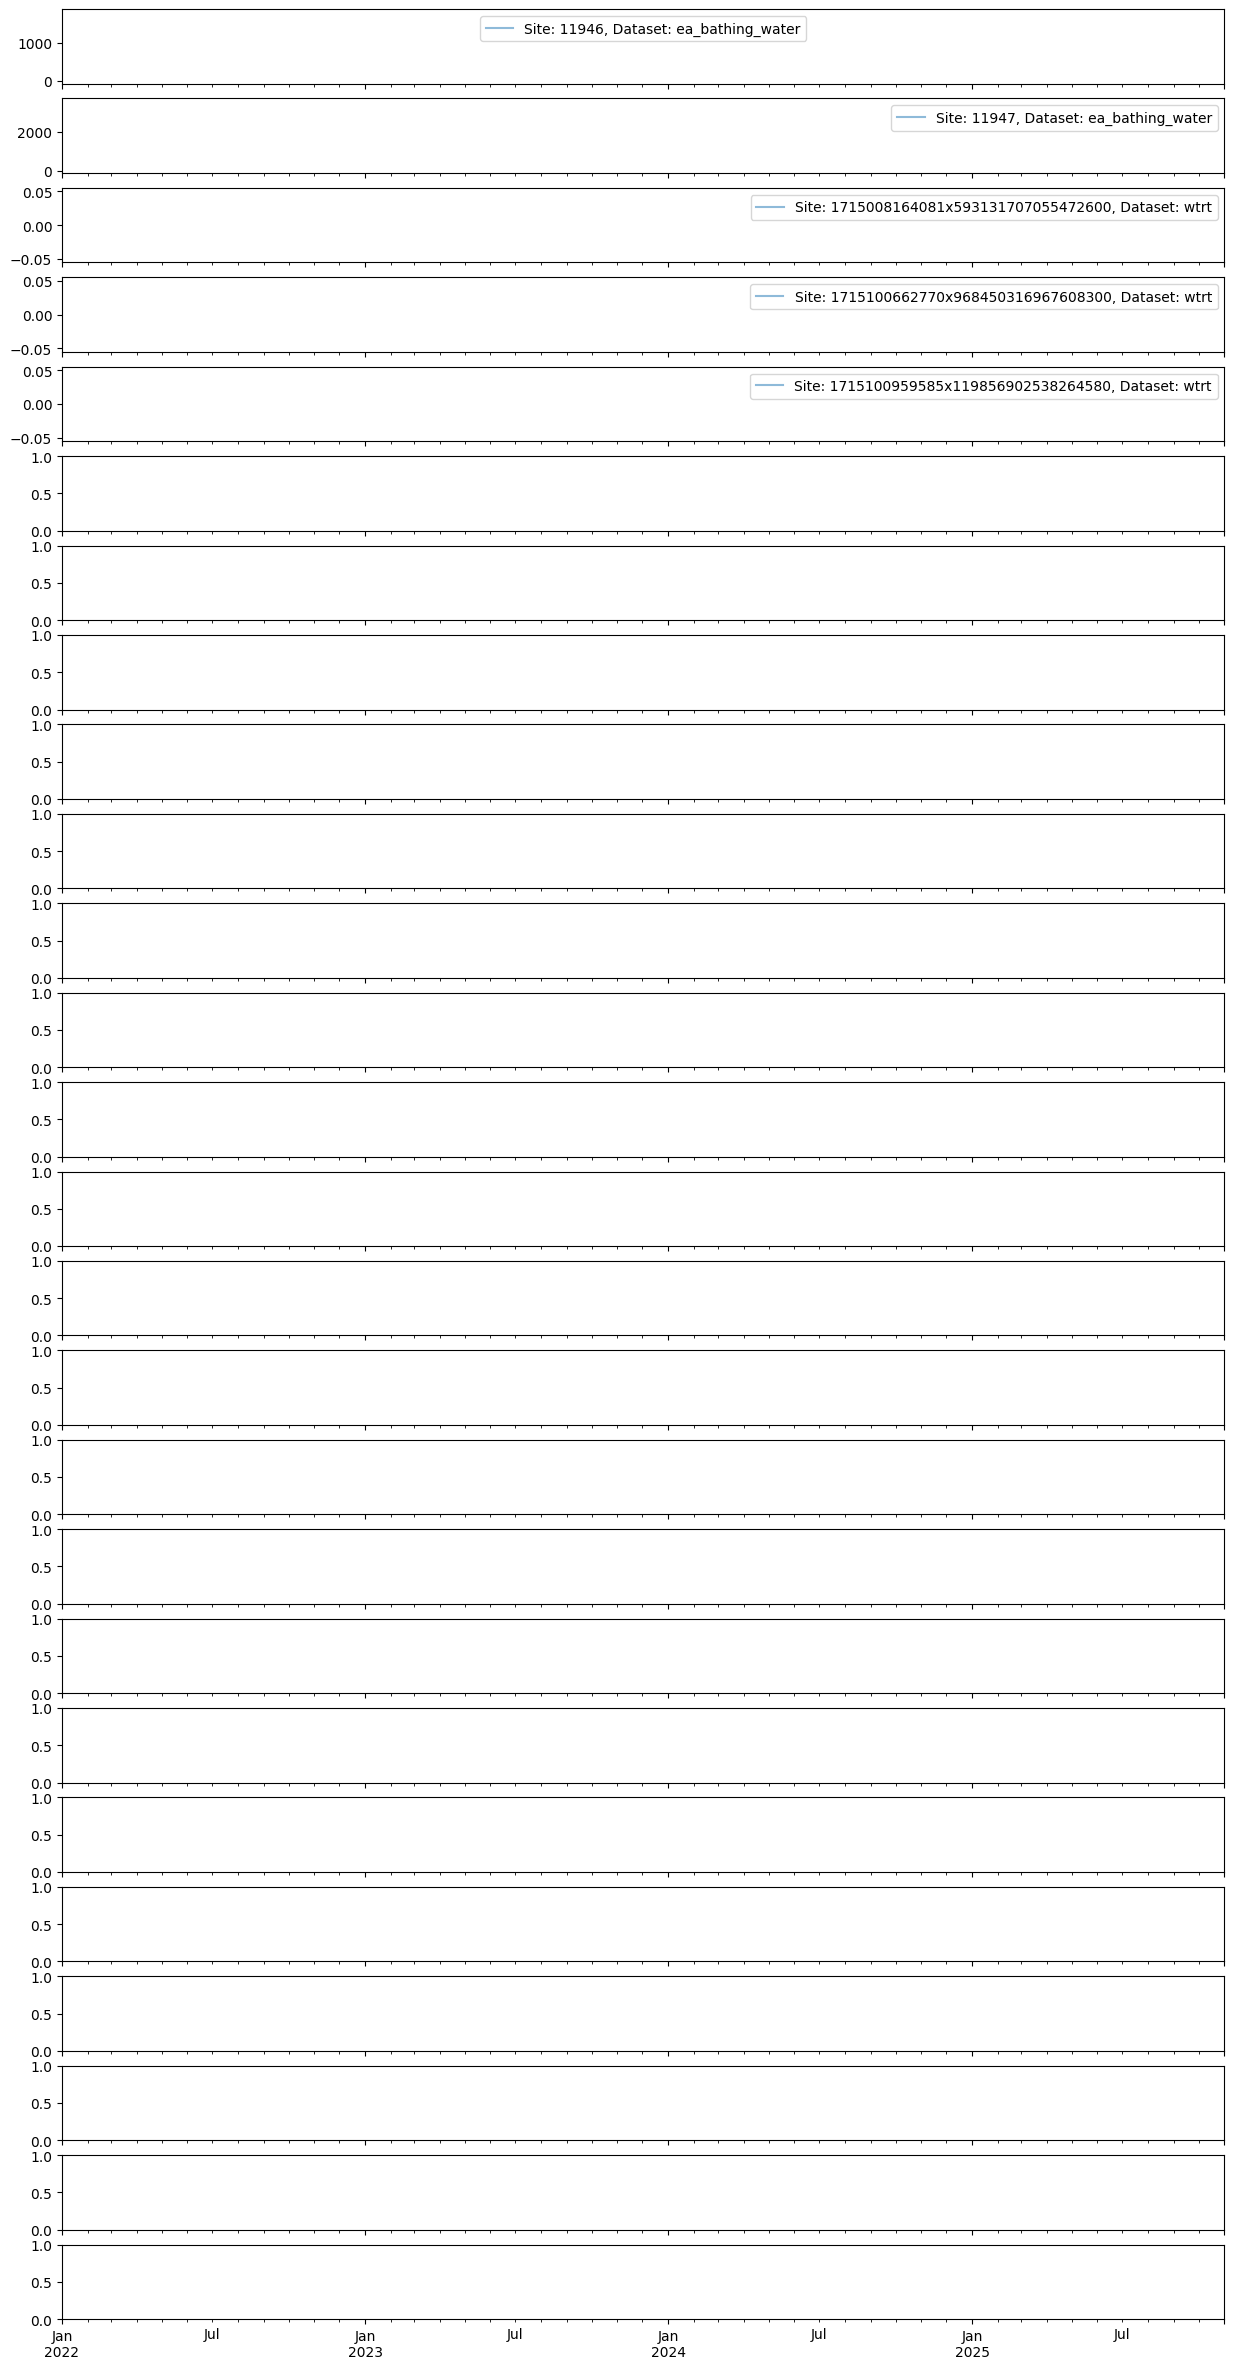

In [89]:
no_dfs = len(ecoli_timeseries_dfs)

fig, ax = plt.subplots(no_dfs, figsize=(15, 30), sharex=True)

dates_complete = pd.date_range(start='2022-01-01', end='2025-11-01', freq='D')

for i, (df, key) in enumerate(zip(ecoli_timeseries_dfs.values(), ecoli_timeseries_dfs.keys())):
    df['datetime'] = df['datetime'].dt.floor('D') # Keep date only, ignore time of measurement
    df = df.set_index('datetime').reindex(dates_complete).reset_index().rename(columns={'index': 'datetime'})
    df.plot(x='datetime', y='escherichia coli count', ax=ax[i], legend=False, alpha=0.5, label = f'Site: {key[0]}, Dataset: {key[1]}')
    ax[i].legend()